# AGP OTU distribution and preprocessing characteristics

This notebook is designed for **Section 4.1: Distribution and preprocessing characteristics of the AGP OTU data**.

It focuses on:
1. loading the raw AGP OTU count matrix and taxonomy map,
2. collapsing counts to **order** and **genus** level,
3. plotting stacked relative-abundance profiles similar to your example figure,
4. comparing the distribution of **raw counts** and **log1p-transformed counts**,
5. exporting figures and compact summary tables for thesis writing.

The path conventions below follow the same structure used in your existing RF/PCA notebook.


In [1]:
# ================================
# 0) Configuration
# ================================
from pathlib import Path
import os
os.chdir("/scratch/liuhon33/parallel/AGPMicrobiomeHostPredictions")

# Reuse the same default path structure as your RF/PCA notebook
otu_file_path = Path("./Data/Cleaned_data/AGP_Otu_Data.csv")
taxa_map_path = Path("./Data/Raw_Data/taxa_md5.xls")
metadata_file_path = Path("./Data/Cleaned_data/processed_metadata.csv")  # optional; only used for sample alignment if present

otu_index_col = 0
metadata_index_col = "sample_name"

# Output directory
output_dir = Path("./hongrui_result/AGP_OTU_distribution_characterization/")
output_dir.mkdir(parents=True, exist_ok=True)

# Plot controls
n_samples_show_order = 250     # number of samples to display in the order-level stacked bar plot
n_samples_show_genus = 200     # number of samples to display in the genus-level stacked bar plot
top_n_orders = 10              # keep top N most abundant orders, collapse the rest into "Others"
top_n_genera = 15              # keep top N most abundant genera, collapse the rest into "Others"

# OTU filtering threshold for one optional summary
abundance_threshold = 0.0001

# Whether to align OTU rows to metadata rows when metadata is available
align_to_metadata = True

print("OTU path:", otu_file_path)
print("Taxa map path:", taxa_map_path)
print("Metadata path:", metadata_file_path)
print("Output dir:", output_dir.resolve())


OTU path: Data/Cleaned_data/AGP_Otu_Data.csv
Taxa map path: Data/Raw_Data/taxa_md5.xls
Metadata path: Data/Cleaned_data/processed_metadata.csv
Output dir: /scratch/liuhon33/parallel/AGPMicrobiomeHostPredictions/hongrui_result/AGP_OTU_distribution_characterization


In [2]:
# ================================
# 1) Imports
# ================================
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 30)


In [3]:
# ================================
# 2) Helper functions
# ================================
def read_taxa_map(path: Path) -> pd.DataFrame:
    taxa_df = pd.read_csv(path, sep="\t", header=0, index_col=0, engine="python")
    taxa_df.index = taxa_df.index.astype(str).str.strip()
    return taxa_df

def clean_tax_strings(series: pd.Series, unknown_label: str) -> pd.Series:
    s = series.copy()
    s = s.fillna(unknown_label).astype(str).str.strip()
    s = s.replace({
        "": unknown_label,
        "nan": unknown_label,
        "NaN": unknown_label,
        "NA": unknown_label,
        "None": unknown_label,
        "Unassigned": unknown_label,
    })
    return s

def find_tax_col(df: pd.DataFrame, level: str) -> str:
    # strict exact/case-insensitive match first
    for col in df.columns:
        if str(col).strip().lower() == level.lower():
            return col
    # fallback: partial match
    for col in df.columns:
        if level.lower() in str(col).strip().lower():
            return col
    raise KeyError(f"Could not find taxonomy level '{level}' in taxa map. Available columns: {list(df.columns)}")

def prefix_tax_label(values: pd.Series, prefix: str) -> pd.Series:
    values = values.astype(str).str.strip()
    return values.map(lambda x: x if x.startswith(prefix) else f"{prefix}{x}")

def build_taxonomy_lookup(otu_cols: pd.Index, taxa_df: pd.DataFrame) -> pd.DataFrame:
    otu_md5 = pd.Index([str(x).strip() for x in otu_cols], name="otu_md5")

    level_prefix = {
        "Phylum": "p__",
        "Class": "c__",
        "Order": "o__",
        "Family": "f__",
        "Genus": "g__",
    }

    lookup = pd.DataFrame(index=otu_md5)

    for level, prefix in level_prefix.items():
        col = find_tax_col(taxa_df, level)
        clean = clean_tax_strings(taxa_df[col], f"Unclassified{level}")
        clean = prefix_tax_label(clean, prefix)
        lookup[level] = clean.reindex(otu_md5).fillna(f"{prefix}Unmapped")

    return lookup

def collapse_counts_by_level(otu_counts: pd.DataFrame, taxonomy_lookup: pd.DataFrame, level: str) -> pd.DataFrame:
    labels = taxonomy_lookup.loc[otu_counts.columns, level]
    collapsed = otu_counts.T.groupby(labels).sum().T
    return collapsed

def to_relative_abundance(df: pd.DataFrame) -> pd.DataFrame:
    denom = df.sum(axis=1).replace(0, np.nan)
    rel = df.div(denom, axis=0).fillna(0)
    return rel

def collapse_to_top_taxa(rel_df: pd.DataFrame, top_n: int) -> pd.DataFrame:
    mean_abund = rel_df.mean(axis=0).sort_values(ascending=False)
    top_taxa = mean_abund.head(top_n).index.tolist()
    out = rel_df[top_taxa].copy()
    remainder = 1 - out.sum(axis=1)
    remainder = remainder.clip(lower=0)
    out["Others"] = remainder
    return out, mean_abund

def sort_samples_for_composition(rel_df: pd.DataFrame) -> pd.DataFrame:
    # Sort using all displayed taxa from most important to least important
    sort_cols = [c for c in rel_df.columns if c != "Others"] + ["Others"]
    return rel_df.sort_values(by=sort_cols, ascending=False)

def thin_samples(df: pd.DataFrame, n_show: int | None) -> pd.DataFrame:
    if n_show is None or n_show >= len(df):
        return df.copy()
    idx = np.linspace(0, len(df) - 1, n_show).round().astype(int)
    return df.iloc[idx].copy()

def make_stacked_barplot(rel_df: pd.DataFrame,
                         title: str,
                         ylabel: str = "Relative abundance",
                         figsize=(16, 6),
                         outfile: Path | None = None):
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(rel_df))
    bottom = np.zeros(len(rel_df))

    for col in rel_df.columns:
        vals = rel_df[col].to_numpy()
        ax.bar(x, vals, bottom=bottom, width=0.95, label=col)
        bottom += vals

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Samples (ordered by composition)")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.0)
    ax.set_xlim(-0.5, len(rel_df) - 0.5)
    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
        title=None,
        ncol=1
    )
    plt.tight_layout()

    if outfile is not None:
        fig.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()

def flatten_nonzero_values(df: pd.DataFrame) -> np.ndarray:
    arr = df.to_numpy().ravel()
    arr = arr[np.isfinite(arr)]
    arr = arr[arr > 0]
    return arr

def plot_raw_vs_log_distribution(raw_values: np.ndarray,
                                 title_prefix: str,
                                 bins_raw: int = 100,
                                 bins_log: int = 100,
                                 outfile: Path | None = None):
    log_values = np.log1p(raw_values)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(raw_values, bins=bins_raw)
    axes[0].set_title(f"{title_prefix}: raw non-zero values")
    axes[0].set_xlabel("Raw count / abundance")
    axes[0].set_ylabel("Frequency")
    axes[0].set_yscale("log")

    axes[1].hist(log_values, bins=bins_log)
    axes[1].set_title(f"{title_prefix}: log1p-transformed non-zero values")
    axes[1].set_xlabel("log(x + 1)")
    axes[1].set_ylabel("Frequency")
    axes[1].set_yscale("log")

    plt.tight_layout()
    if outfile is not None:
        fig.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()

def plot_feature_prevalence(df: pd.DataFrame,
                            title: str,
                            outfile: Path | None = None):
    prevalence = (df > 0).mean(axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(prevalence, bins=40)
    axes[0].set_title(f"{title}: feature prevalence")
    axes[0].set_xlabel("Proportion of samples with non-zero value")
    axes[0].set_ylabel("Number of features")

    axes[1].hist(np.log1p(prevalence), bins=40)
    axes[1].set_title(f"{title}: log1p(prevalence)")
    axes[1].set_xlabel("log(prevalence + 1)")
    axes[1].set_ylabel("Number of features")

    plt.tight_layout()
    if outfile is not None:
        fig.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()

def summarize_table(df: pd.DataFrame, name: str) -> pd.DataFrame:
    nonzero = df.to_numpy() > 0
    total_entries = df.shape[0] * df.shape[1]
    out = pd.DataFrame({
        "dataset": [name],
        "n_samples": [df.shape[0]],
        "n_features": [df.shape[1]],
        "total_entries": [total_entries],
        "nonzero_entries": [int(nonzero.sum())],
        "sparsity": [1 - nonzero.mean()],
        "median_row_sum": [df.sum(axis=1).median()],
        "mean_row_sum": [df.sum(axis=1).mean()],
    })
    return out

def save_csv(df: pd.DataFrame, filename: str):
    path = output_dir / filename
    df.to_csv(path, index=True)
    print("Saved:", path)


In [4]:
# ================================
# 3) Load OTU table, optional metadata, and taxa map
# ================================
otu_df = pd.read_csv(otu_file_path, index_col=otu_index_col)
otu_df.index = otu_df.index.astype(str).str.strip()
otu_df.columns = otu_df.columns.astype(str).str.strip()

print("Raw OTU table shape:", otu_df.shape)

metadata_df = None
if metadata_file_path.exists():
    metadata_df = pd.read_csv(metadata_file_path, index_col=metadata_index_col)
    metadata_df.index = metadata_df.index.astype(str).str.strip()
    print("Metadata shape:", metadata_df.shape)

    if align_to_metadata:
        common_samples = metadata_df.index.intersection(otu_df.index)
        otu_df = otu_df.loc[common_samples].copy()
        metadata_df = metadata_df.loc[common_samples].copy()
        print("After sample alignment:", otu_df.shape, "(OTU) and", metadata_df.shape, "(metadata)")
else:
    print("Metadata file not found. Continuing with OTU data only.")

taxa_df = read_taxa_map(taxa_map_path)
print("Taxa map shape:", taxa_df.shape)

taxonomy_lookup = build_taxonomy_lookup(otu_df.columns, taxa_df)
print("Taxonomy lookup shape:", taxonomy_lookup.shape)

display(taxonomy_lookup.head())


Raw OTU table shape: (10366, 4460)
Metadata shape: (9559, 48)
After sample alignment: (9559, 4460) (OTU) and (9559, 48) (metadata)
Taxa map shape: (99980, 7)
Taxonomy lookup shape: (4460, 5)


,Phylum,Class,Order,Family,Genus
otu_md5,,,,,
ef63210b495a2604f8a624c1dc463967,p__Bacteroidetes,c__Bacteroidia,o__Bacteroidales,f__Bacteroidaceae,g__Bacteroides
fee9d92edb4dcf51e6ac35e0c68647f0,p__Bacteroidetes,c__Bacteroidia,o__Bacteroidales,f__Bacteroidaceae,g__Bacteroides
26beb3295e398c95d786ef5c439691e0,p__Firmicutes,c__Clostridia,o__Clostridiales,f__Ruminococcaceae,g__Faecalibacterium
48645283f7e325b651305bed98b7f1cd,p__Bacteroidetes,c__Bacteroidia,o__Bacteroidales,f__Bacteroidaceae,g__Bacteroides
6bfe71f580ccfa342a0ddd97cb0f4170,p__Firmicutes,c__Clostridia,o__Clostridiales,f__Ruminococcaceae,g__Faecalibacterium


In [5]:
# ================================
# 4) Quick preview: what the raw data look like
# ================================
print("Preview of raw OTU counts:")
display(otu_df.iloc[:5, :8])

print("\nPreview of taxonomy labels for the first OTUs:")
display(taxonomy_lookup.head(10))

summary_raw = summarize_table(otu_df, "raw_otu")
display(summary_raw)
summary_raw.to_csv(output_dir / "summary_raw_otu.csv", index=False)


Preview of raw OTU counts:


,ef63210b495a2604f8a624c1dc463967,fee9d92edb4dcf51e6ac35e0c68647f0,26beb3295e398c95d786ef5c439691e0,48645283f7e325b651305bed98b7f1cd,6bfe71f580ccfa342a0ddd97cb0f4170,daf013c0818a88a2d9734e537a165d78,794e8123c6bdcfc2191d386b0c00b1df,0ec7ebe2185e6fedace92df4c732a35f
ERR1073439,577,51,438,169,114,44,130,9
ERR1072625,0,0,0,941,96,204,480,0
ERR1089664,0,0,0,0,14,0,6,0
ERR1075599,0,3,431,807,651,621,77,0
ERR1073066,0,995,266,706,450,331,251,0



Preview of taxonomy labels for the first OTUs:


,Phylum,Class,Order,Family,Genus
otu_md5,,,,,
ef63210b495a2604f8a624c1dc463967,p__Bacteroidetes,c__Bacteroidia,o__Bacteroidales,f__Bacteroidaceae,g__Bacteroides
fee9d92edb4dcf51e6ac35e0c68647f0,p__Bacteroidetes,c__Bacteroidia,o__Bacteroidales,f__Bacteroidaceae,g__Bacteroides
26beb3295e398c95d786ef5c439691e0,p__Firmicutes,c__Clostridia,o__Clostridiales,f__Ruminococcaceae,g__Faecalibacterium
48645283f7e325b651305bed98b7f1cd,p__Bacteroidetes,c__Bacteroidia,o__Bacteroidales,f__Bacteroidaceae,g__Bacteroides
6bfe71f580ccfa342a0ddd97cb0f4170,p__Firmicutes,c__Clostridia,o__Clostridiales,f__Ruminococcaceae,g__Faecalibacterium
daf013c0818a88a2d9734e537a165d78,p__Firmicutes,c__Clostridia,o__Clostridiales,f__Lachnospiraceae,g__Roseburia
794e8123c6bdcfc2191d386b0c00b1df,p__Bacteroidetes,c__Bacteroidia,o__Bacteroidales,f__Bacteroidaceae,g__Bacteroides
0ec7ebe2185e6fedace92df4c732a35f,p__Bacteroidetes,c__Bacteroidia,o__Bacteroidales,f__Prevotellaceae,g__Prevotella_9
5d013785e9ee61de8017ddd2a6ca4f99,p__Firmicutes,c__Clostridia,o__Clostridiales,f__Ruminococcaceae,g__Faecalibacterium


,dataset,n_samples,n_features,total_entries,nonzero_entries,sparsity,median_row_sum,mean_row_sum
0,raw_otu,9559,4460,42633140,1635933,0.961628,10000.0,10000.0


## Order-level composition

This section collapses OTU counts to the **order** level by summing all OTUs assigned to the same order.  
The first plot is the order-level analogue of your example stacked bar plot.


,dataset,n_samples,n_features,total_entries,nonzero_entries,sparsity,median_row_sum,mean_row_sum
0,order_collapsed,9559,53,506627,143158,0.717429,10000.0,10000.0


,mean_relative_abundance,prevalence
Order,,
o__Clostridiales,0.448385,0.999582
o__Bacteroidales,0.386314,0.999268
o__Enterobacteriales,0.024583,0.476410
o__Verrucomicrobiales,0.021167,0.687833
o__Selenomonadales,0.020600,0.982006
o__Burkholderiales,0.011846,0.840988
o__Bifidobacteriales,0.011619,0.767026
o__Erysipelotrichales,0.010966,0.991631
o__Pseudomonadales,0.010912,0.292918


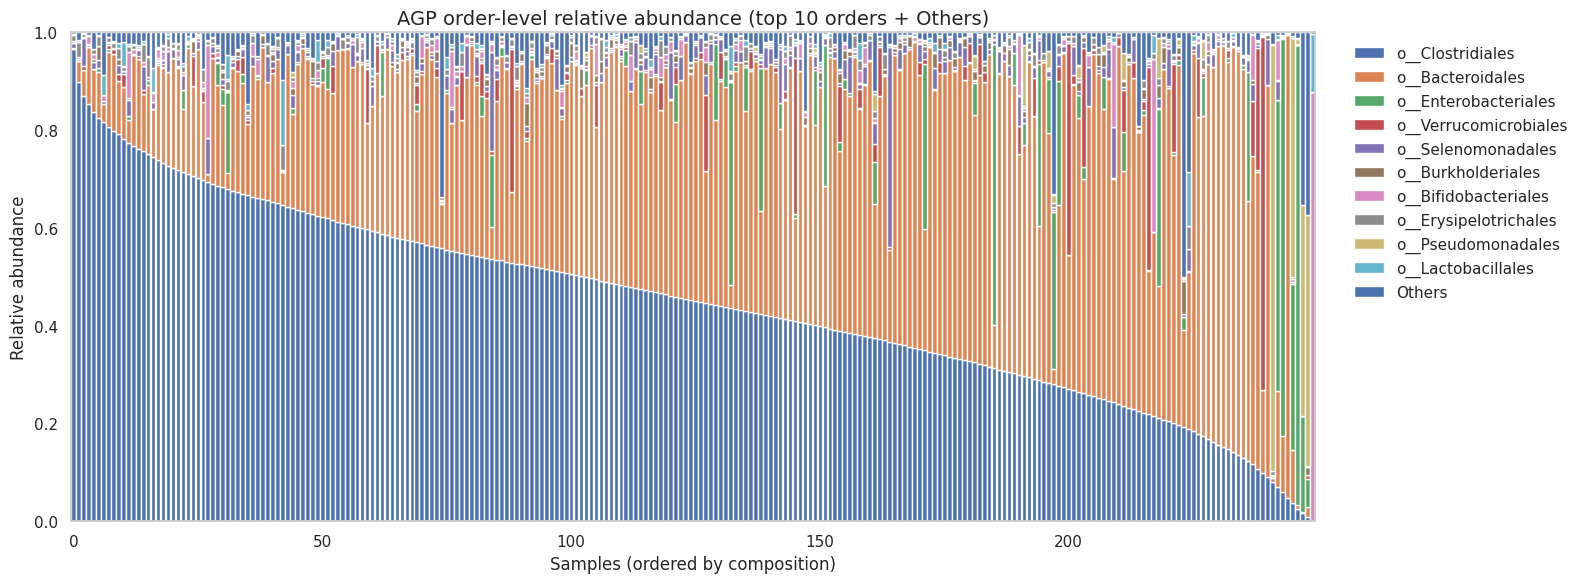

In [6]:
# ================================
# 5) Collapse to order level
# ================================
order_counts = collapse_counts_by_level(otu_df, taxonomy_lookup, level="Order")
order_rel = to_relative_abundance(order_counts)

summary_order = summarize_table(order_counts, "order_collapsed")
display(summary_order)
summary_order.to_csv(output_dir / "summary_order_collapsed.csv", index=False)

# Top-order summary table
order_mean_abund = order_rel.mean(axis=0).sort_values(ascending=False)
order_prevalence = (order_counts > 0).mean(axis=0).sort_values(ascending=False)

order_summary = pd.DataFrame({
    "mean_relative_abundance": order_mean_abund,
    "prevalence": order_prevalence.reindex(order_mean_abund.index)
}).sort_values("mean_relative_abundance", ascending=False)

display(order_summary.head(20))
order_summary.to_csv(output_dir / "order_summary.csv")

# Prepare stacked composition plot
order_rel_top, _ = collapse_to_top_taxa(order_rel, top_n=top_n_orders)
order_rel_top_sorted = sort_samples_for_composition(order_rel_top)
order_rel_plot = thin_samples(order_rel_top_sorted, n_samples_show_order)

make_stacked_barplot(
    order_rel_plot,
    title=f"AGP order-level relative abundance (top {top_n_orders} orders + Others)",
    outfile=output_dir / "order_level_relative_abundance_stacked.png"
)


## Genus-level composition

This is the same idea at the **genus** level.  
Because genera are more granular and noisier than orders, the plot keeps more taxa and may look visually denser.


,dataset,n_samples,n_features,total_entries,nonzero_entries,sparsity,median_row_sum,mean_row_sum
0,genus_collapsed,9559,311,2972849,600709,0.797935,10000.0,10000.0


,mean_relative_abundance,prevalence
Genus,,
g__Bacteroides,0.262755,0.992991
g__UnclassifiedGenus,0.088845,0.999058
g__Faecalibacterium,0.082260,0.970499
g__Roseburia,0.047934,0.969767
g__Prevotella_9,0.040025,0.409666
g__Alistipes,0.027187,0.941312
g__Blautia,0.027162,0.987656
g__Parabacteroides,0.023537,0.929595
g__Subdoligranulum,0.022970,0.927084


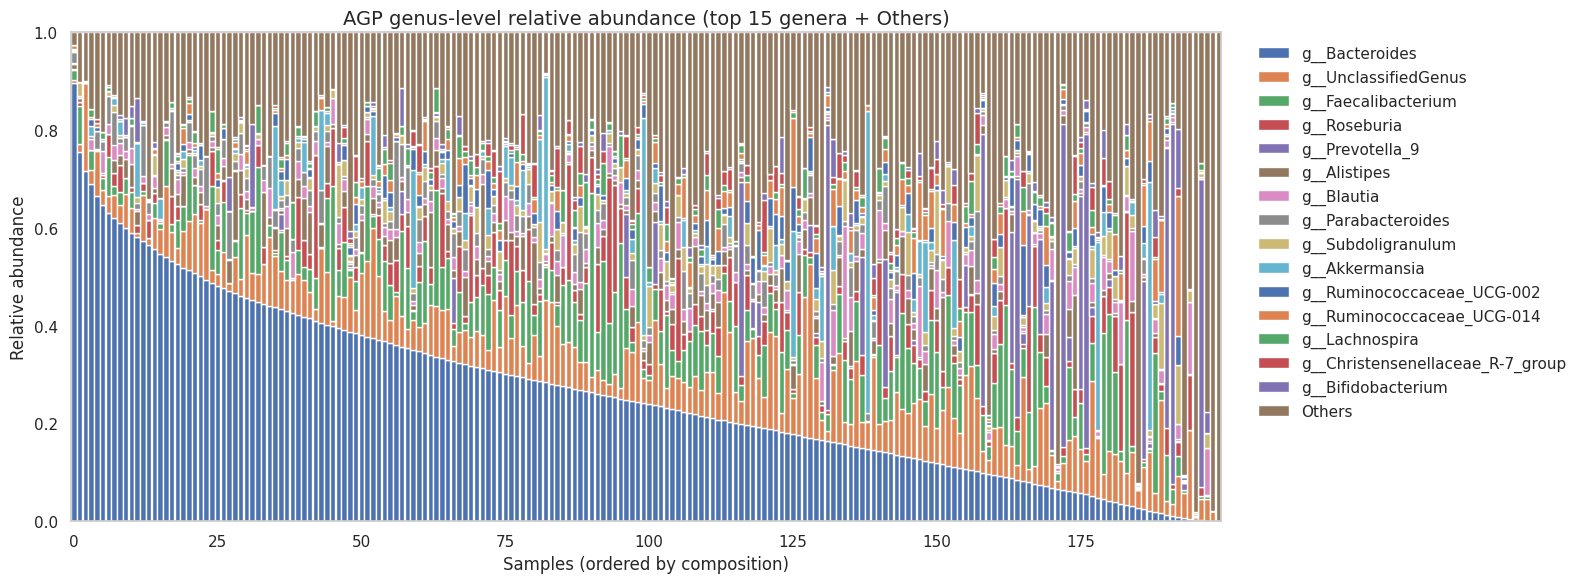

In [7]:
# ================================
# 6) Collapse to genus level
# ================================
genus_counts = collapse_counts_by_level(otu_df, taxonomy_lookup, level="Genus")
genus_rel = to_relative_abundance(genus_counts)

summary_genus = summarize_table(genus_counts, "genus_collapsed")
display(summary_genus)
summary_genus.to_csv(output_dir / "summary_genus_collapsed.csv", index=False)

genus_mean_abund = genus_rel.mean(axis=0).sort_values(ascending=False)
genus_prevalence = (genus_counts > 0).mean(axis=0).sort_values(ascending=False)

genus_summary = pd.DataFrame({
    "mean_relative_abundance": genus_mean_abund,
    "prevalence": genus_prevalence.reindex(genus_mean_abund.index)
}).sort_values("mean_relative_abundance", ascending=False)

display(genus_summary.head(25))
genus_summary.to_csv(output_dir / "genus_summary.csv")

genus_rel_top, _ = collapse_to_top_taxa(genus_rel, top_n=top_n_genera)
genus_rel_top_sorted = sort_samples_for_composition(genus_rel_top)
genus_rel_plot = thin_samples(genus_rel_top_sorted, n_samples_show_genus)

make_stacked_barplot(
    genus_rel_plot,
    title=f"AGP genus-level relative abundance (top {top_n_genera} genera + Others)",
    outfile=output_dir / "genus_level_relative_abundance_stacked.png"
)


## Raw versus log-transformed distributions

These plots compare the distribution of **non-zero values** before and after `log(x + 1)` transformation.  
They are useful for showing why the transformation was applied before downstream modeling.


Number of non-zero OTU entries: 1635933
Raw OTU non-zero summary:


,raw_nonzero_otu
count,1.635933e+06
mean,5.843149e+01
std,2.015523e+02
min,1.000000e+00
25%,5.000000e+00
50%,1.400000e+01
75%,3.900000e+01
90%,1.150000e+02
99%,7.990000e+02
max,9.386000e+03


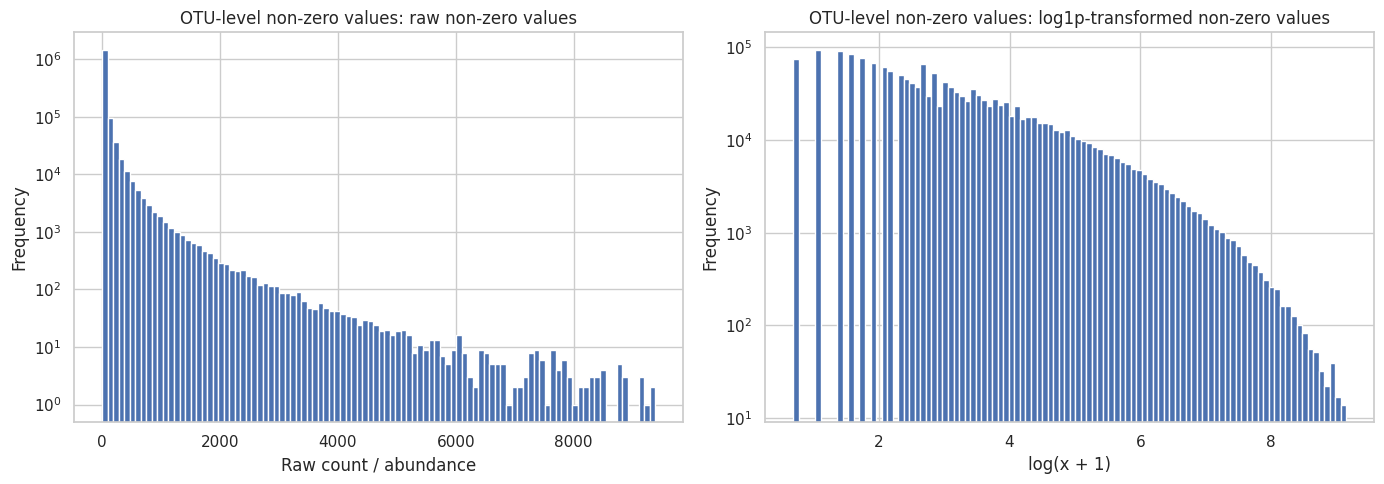

In [8]:
# ================================
# 7) Raw vs log1p distribution: OTU-level values
# ================================
otu_nonzero = flatten_nonzero_values(otu_df)

print("Number of non-zero OTU entries:", len(otu_nonzero))
print("Raw OTU non-zero summary:")
display(pd.Series(otu_nonzero).describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).to_frame("raw_nonzero_otu"))

plot_raw_vs_log_distribution(
    otu_nonzero,
    title_prefix="OTU-level non-zero values",
    outfile=output_dir / "otu_raw_vs_log1p_distribution.png"
)


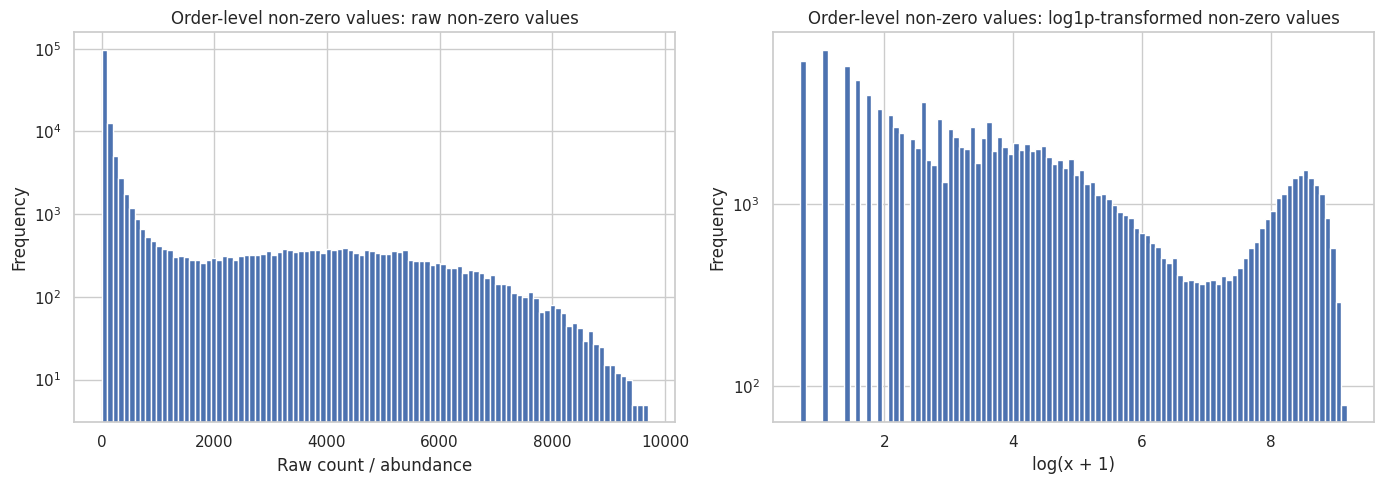

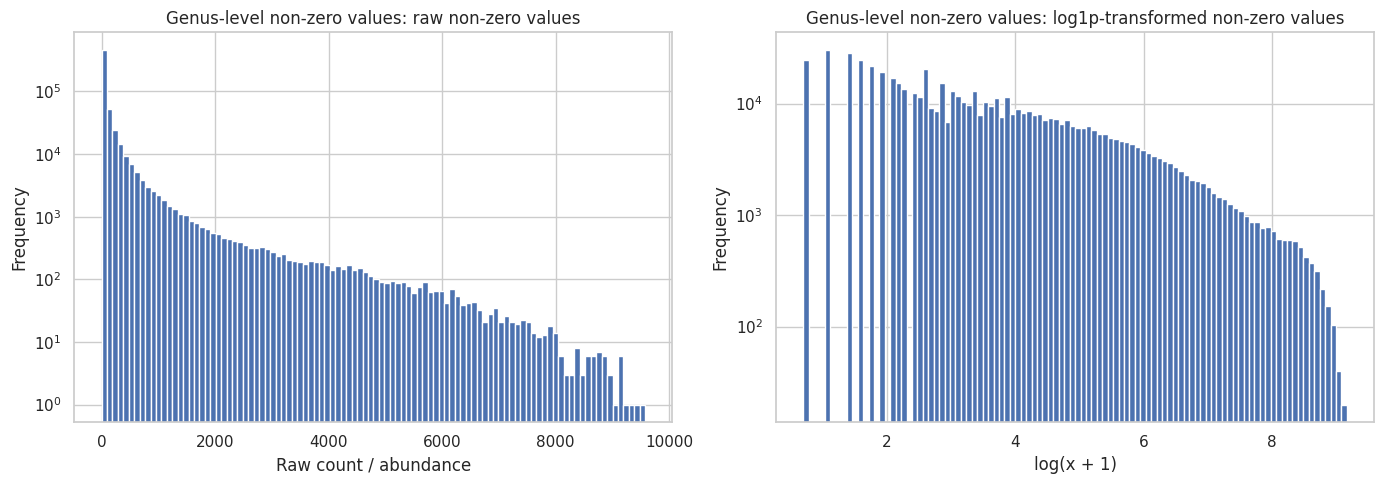

In [9]:
# ================================
# 8) Raw vs log1p distribution: order- and genus-collapsed values
# ================================
order_nonzero = flatten_nonzero_values(order_counts)
genus_nonzero = flatten_nonzero_values(genus_counts)

plot_raw_vs_log_distribution(
    order_nonzero,
    title_prefix="Order-level non-zero values",
    outfile=output_dir / "order_raw_vs_log1p_distribution.png"
)

plot_raw_vs_log_distribution(
    genus_nonzero,
    title_prefix="Genus-level non-zero values",
    outfile=output_dir / "genus_raw_vs_log1p_distribution.png"
)


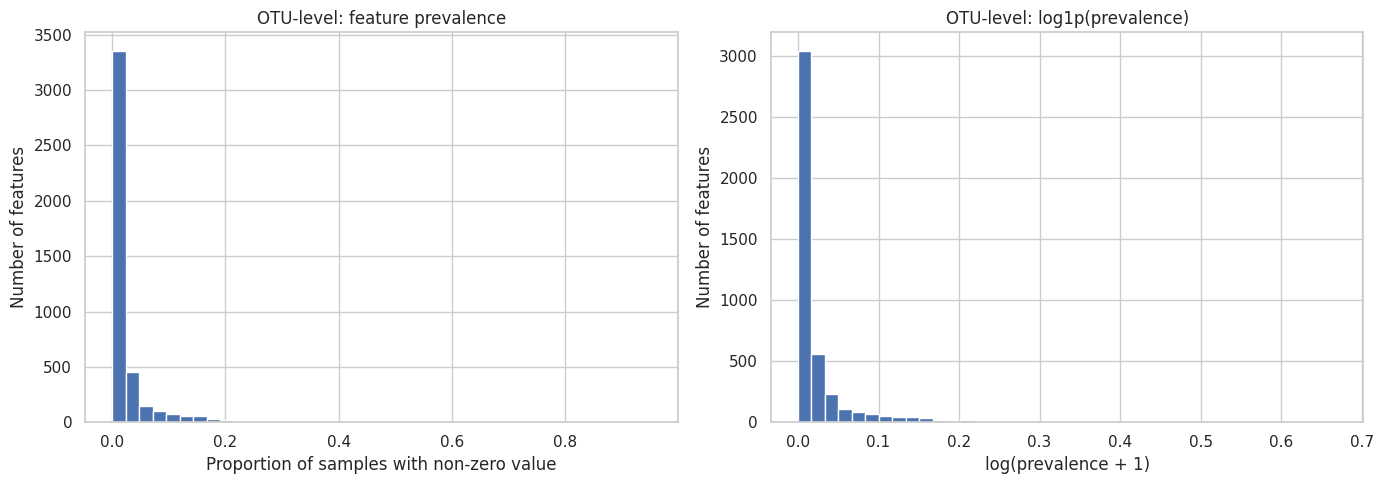

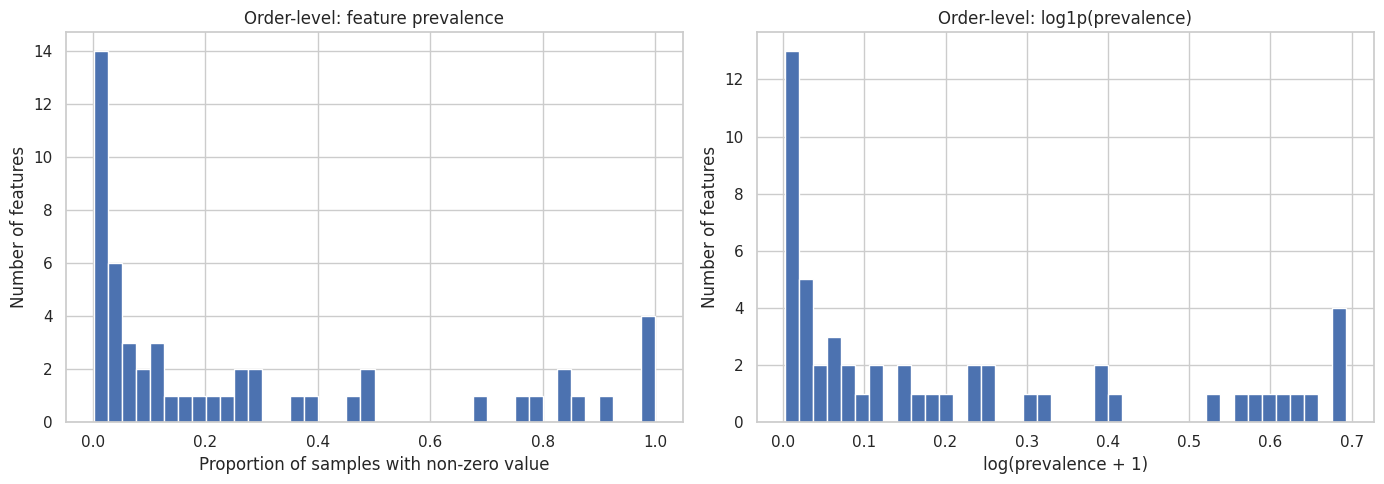

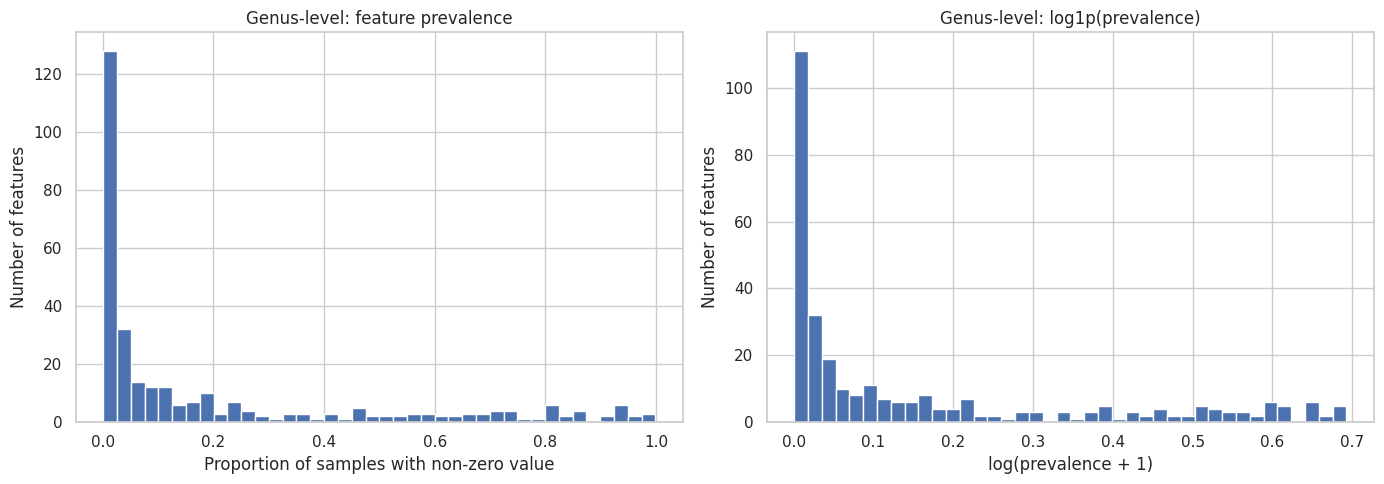

In [10]:
# ================================
# 9) Prevalence / population distribution
# ================================
plot_feature_prevalence(
    otu_df,
    title="OTU-level",
    outfile=output_dir / "otu_feature_prevalence.png"
)

plot_feature_prevalence(
    order_counts,
    title="Order-level",
    outfile=output_dir / "order_feature_prevalence.png"
)

plot_feature_prevalence(
    genus_counts,
    title="Genus-level",
    outfile=output_dir / "genus_feature_prevalence.png"
)


## Optional filter summary

This reproduces the same abundance-based filtering logic used in your RF/PCA workflow, so you can report the number of OTUs retained after filtering if needed.


In [11]:
# ================================
# 10) Optional abundance-filter summary
# ================================
otu_rel = to_relative_abundance(otu_df)
mean_rel_abund = otu_rel.mean(axis=0)
otus_to_keep = mean_rel_abund[mean_rel_abund > abundance_threshold].index

otu_df_filtered = otu_df[otus_to_keep].copy()
otu_df_log1p = np.log1p(otu_df_filtered)

filter_summary = pd.DataFrame({
    "n_raw_otus": [otu_df.shape[1]],
    "n_filtered_otus": [otu_df_filtered.shape[1]],
    "abundance_threshold": [abundance_threshold],
    "retention_rate": [otu_df_filtered.shape[1] / otu_df.shape[1]]
})

display(filter_summary)
filter_summary.to_csv(output_dir / "otu_filter_summary.csv", index=False)

print("Filtered OTU table shape:", otu_df_filtered.shape)
print("Log-transformed filtered OTU table shape:", otu_df_log1p.shape)


,n_raw_otus,n_filtered_otus,abundance_threshold,retention_rate
0,4460,819,0.0001,0.183632


Filtered OTU table shape: (9559, 819)
Log-transformed filtered OTU table shape: (9559, 819)


## Compact export block

This final block saves the main processed tables so you can reuse them later without rerunning every step.


In [12]:
# ================================
# 11) Save processed tables
# ================================
order_counts.to_csv(output_dir / "order_counts_collapsed.csv")
order_rel.to_csv(output_dir / "order_relative_abundance.csv")

genus_counts.to_csv(output_dir / "genus_counts_collapsed.csv")
genus_rel.to_csv(output_dir / "genus_relative_abundance.csv")

taxonomy_lookup.to_csv(output_dir / "taxonomy_lookup_used.csv")

print("Saved all main tables to:", output_dir.resolve())
print("\nMain figure files expected:")
for fn in [
    "order_level_relative_abundance_stacked.png",
    "genus_level_relative_abundance_stacked.png",
    "otu_raw_vs_log1p_distribution.png",
    "order_raw_vs_log1p_distribution.png",
    "genus_raw_vs_log1p_distribution.png",
    "otu_feature_prevalence.png",
    "order_feature_prevalence.png",
    "genus_feature_prevalence.png",
]:
    print(" -", output_dir / fn)


Saved all main tables to: /scratch/liuhon33/parallel/AGPMicrobiomeHostPredictions/hongrui_result/AGP_OTU_distribution_characterization

Main figure files expected:
 - hongrui_result/AGP_OTU_distribution_characterization/order_level_relative_abundance_stacked.png
 - hongrui_result/AGP_OTU_distribution_characterization/genus_level_relative_abundance_stacked.png
 - hongrui_result/AGP_OTU_distribution_characterization/otu_raw_vs_log1p_distribution.png
 - hongrui_result/AGP_OTU_distribution_characterization/order_raw_vs_log1p_distribution.png
 - hongrui_result/AGP_OTU_distribution_characterization/genus_raw_vs_log1p_distribution.png
 - hongrui_result/AGP_OTU_distribution_characterization/otu_feature_prevalence.png
 - hongrui_result/AGP_OTU_distribution_characterization/order_feature_prevalence.png
 - hongrui_result/AGP_OTU_distribution_characterization/genus_feature_prevalence.png


### Notes for writing the results section later

The notebook is set up so you can easily report:
- the number of AGP samples and raw OTUs included,
- the number of OTUs retained after abundance filtering,
- the dominant orders and genera by mean relative abundance,
- the strong right-skew of raw counts,
- the compression of extreme values after `log(x + 1)`,
- the high sparsity / uneven prevalence typical of microbiome count data.

Once you run it and inspect the exact outputs, I can help you turn them into a short thesis-style results subsection.


In [13]:
# ================================
# 15) Collapse to family level
# ================================
family_counts = collapse_counts_by_level(otu_df, taxonomy_lookup, level="Family")
family_rel = to_relative_abundance(family_counts)

print("Family-level count matrix shape:", family_counts.shape)
display(family_counts.iloc[:5, :8])

Family-level count matrix shape: (9559, 86)


Family,f__Acidaminococcaceae,f__Actinomycetaceae,f__Aerococcaceae,f__Aeromonadaceae,f__Alcaligenaceae,f__Anaeroplasmataceae,f__Bacillaceae,f__Bacteroidaceae
ERR1073439,0,0,0,0,2,0,0,1511
ERR1072625,41,0,0,0,64,0,0,2354
ERR1089664,0,0,0,0,0,0,0,6
ERR1075599,62,3,4,0,117,35,0,1603
ERR1073066,27,11,0,0,0,0,0,2704


In [14]:
# ================================
# 16) Select the top 5 most abundant families
# ================================
selected_families_manual = [
    # Leave empty to auto-select the top 5 most abundant mapped families
    # Example:
    # "f__Bacteroidaceae",
    # "f__Rikenellaceae",
]

exclude_family_patterns = [
    "Unclassified",
    "Unmapped",
]

family_mean_pct = (family_rel.mean(axis=0) * 100).sort_values(ascending=False)

candidate_families = [
    f for f in family_mean_pct.index
    if not any(pat.lower() in str(f).lower() for pat in exclude_family_patterns)
]

if len(selected_families_manual) > 0:
    selected_families = [f for f in selected_families_manual if f in family_rel.columns]
else:
    selected_families = candidate_families[:5]

if len(selected_families) == 0:
    raise ValueError("No valid selected families found. Please check selected_families_manual or the family labels.")

print("Selected families:")
for f in selected_families:
    print(" -", f)

Selected families:
 - f__Bacteroidaceae
 - f__Ruminococcaceae
 - f__Lachnospiraceae
 - f__Prevotellaceae
 - f__Porphyromonadaceae


In [15]:
# ================================
# 17) Build selected-family percentage table
# ================================
selected_family_pct = family_rel[selected_families].copy() * 100.0
selected_family_logpct = np.log1p(selected_family_pct)

selected_family_summary = pd.DataFrame({
    "mean_percentage": selected_family_pct.mean(axis=0),
    "median_percentage": selected_family_pct.median(axis=0),
    "sd_percentage": selected_family_pct.std(axis=0),
    "prevalence": (family_counts[selected_families] > 0).mean(axis=0),
    "max_percentage": selected_family_pct.max(axis=0),
}).sort_values("mean_percentage", ascending=False)

display(selected_family_summary)
selected_family_summary.to_csv(output_dir / "selected_family_percentage_summary.csv")
print("Saved:", output_dir / "selected_family_percentage_summary.csv")

,mean_percentage,median_percentage,sd_percentage,prevalence,max_percentage
Family,,,,,
f__Bacteroidaceae,26.275518,24.03,17.666740,0.992991,89.68
f__Ruminococcaceae,22.431536,21.77,12.106888,0.996339,67.59
f__Lachnospiraceae,18.916809,17.49,10.875806,0.999268,93.94
f__Prevotellaceae,5.767330,0.28,13.300129,0.803222,93.28
f__Porphyromonadaceae,3.302177,2.36,3.418902,0.969139,57.45


Saved: hongrui_result/AGP_OTU_distribution_characterization/selected_family_percentage_summary.csv


In [16]:
# ================================
# 18) Helper for multi-panel histograms
# ================================
def plot_selected_taxa_histograms(df,
                                  taxa,
                                  title,
                                  xlab,
                                  outfile=None,
                                  bins=30,
                                  ncols=2,
                                  figsize_scale=(7, 4.8)):
    n = len(taxa)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_scale[0] * ncols, figsize_scale[1] * nrows),
        squeeze=False
    )
    axes = axes.flatten()

    for ax, taxon in zip(axes, taxa):
        vals = df[taxon].dropna().to_numpy()
        ax.hist(vals, bins=bins, edgecolor="black", alpha=0.8)
        ax.set_title(str(taxon), fontsize=10)
        ax.set_xlabel(xlab)
        ax.set_ylabel("Number of samples")

    for ax in axes[len(taxa):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=18, fontweight="bold", y=1.02)
    plt.tight_layout()

    if outfile is not None:
        fig.savefig(outfile, dpi=300, bbox_inches="tight")
        print("Saved:", outfile)

    plt.show()

Saved: hongrui_result/AGP_OTU_distribution_characterization/top5_families_percentage_distribution.png


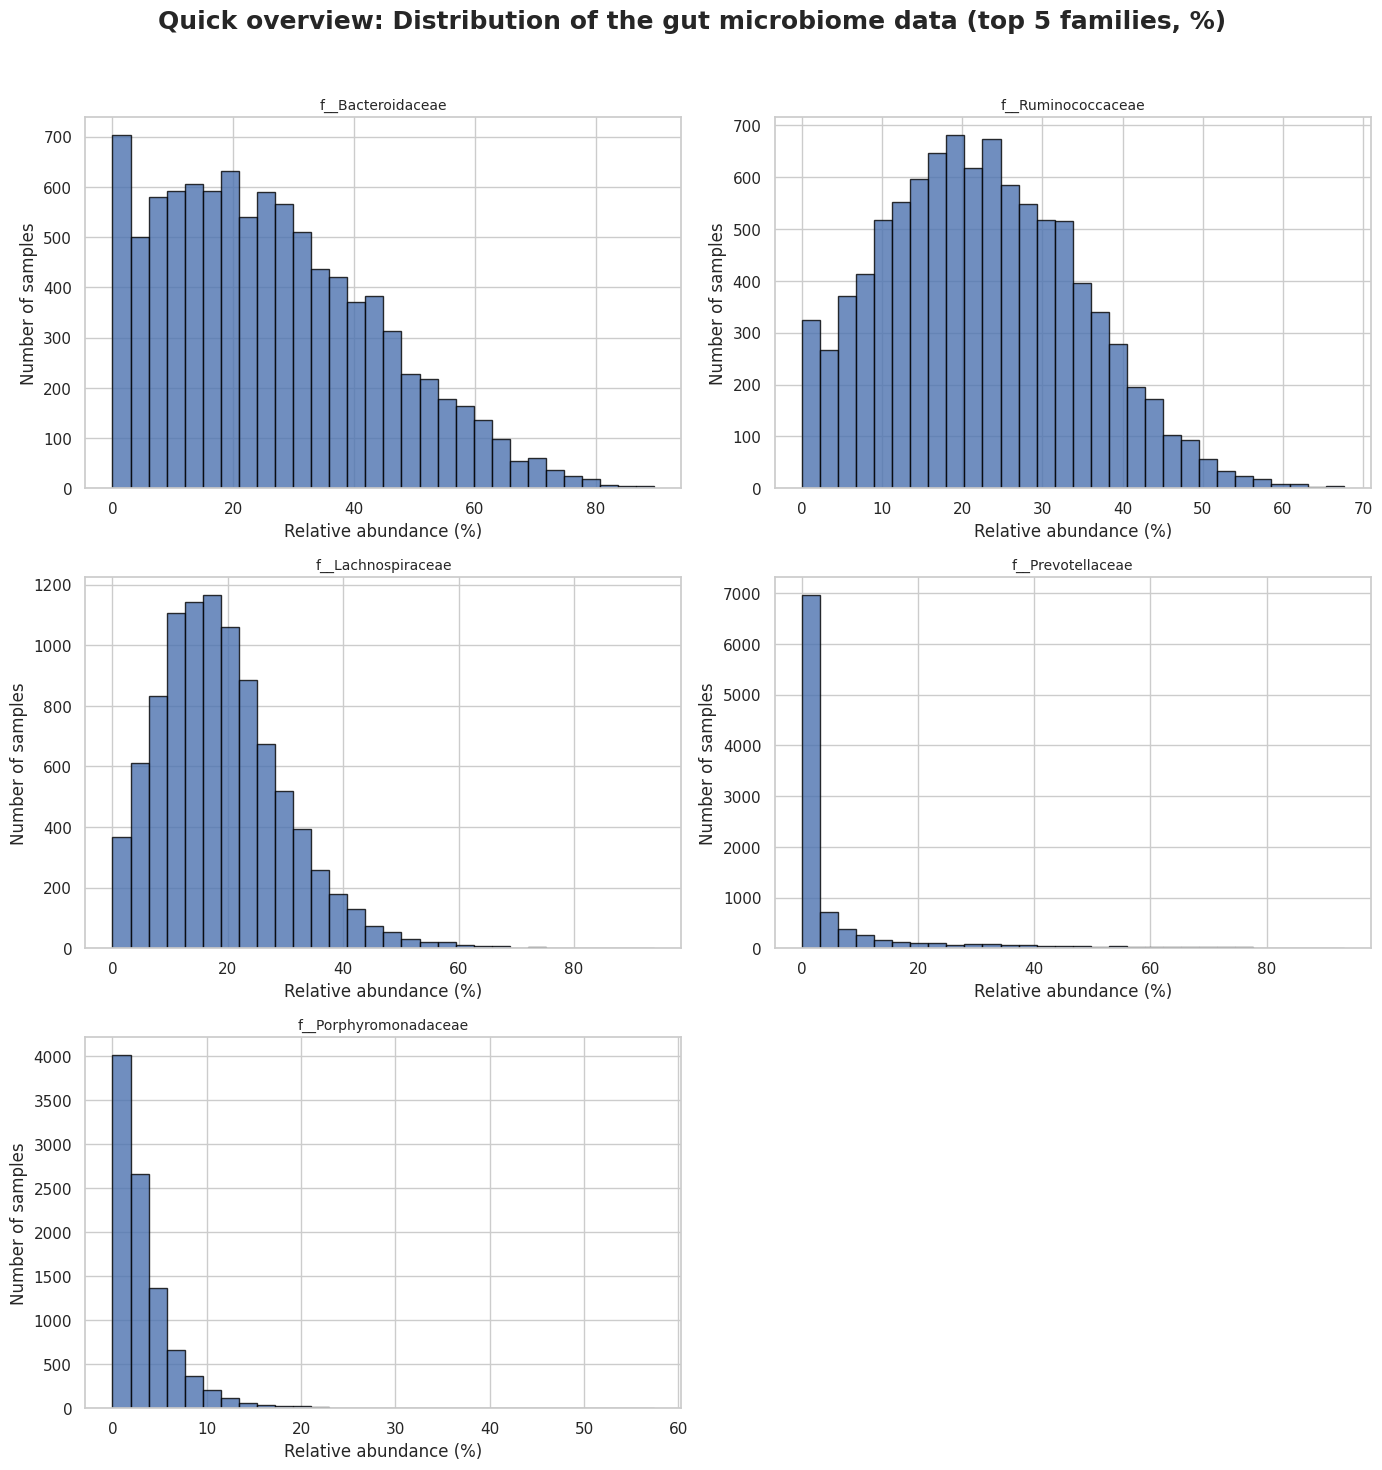

In [17]:
# ================================
# 19) Plot raw percentage distributions for the top 5 families
# ================================
plot_selected_taxa_histograms(
    selected_family_pct,
    taxa=selected_families,
    title="Quick overview: Distribution of the gut microbiome data (top 5 families, %)",
    xlab="Relative abundance (%)",
    outfile=output_dir / "top5_families_percentage_distribution.png",
    bins=30,
    ncols=2
)

Saved: hongrui_result/AGP_OTU_distribution_characterization/top5_families_log1p_percentage_distribution.png


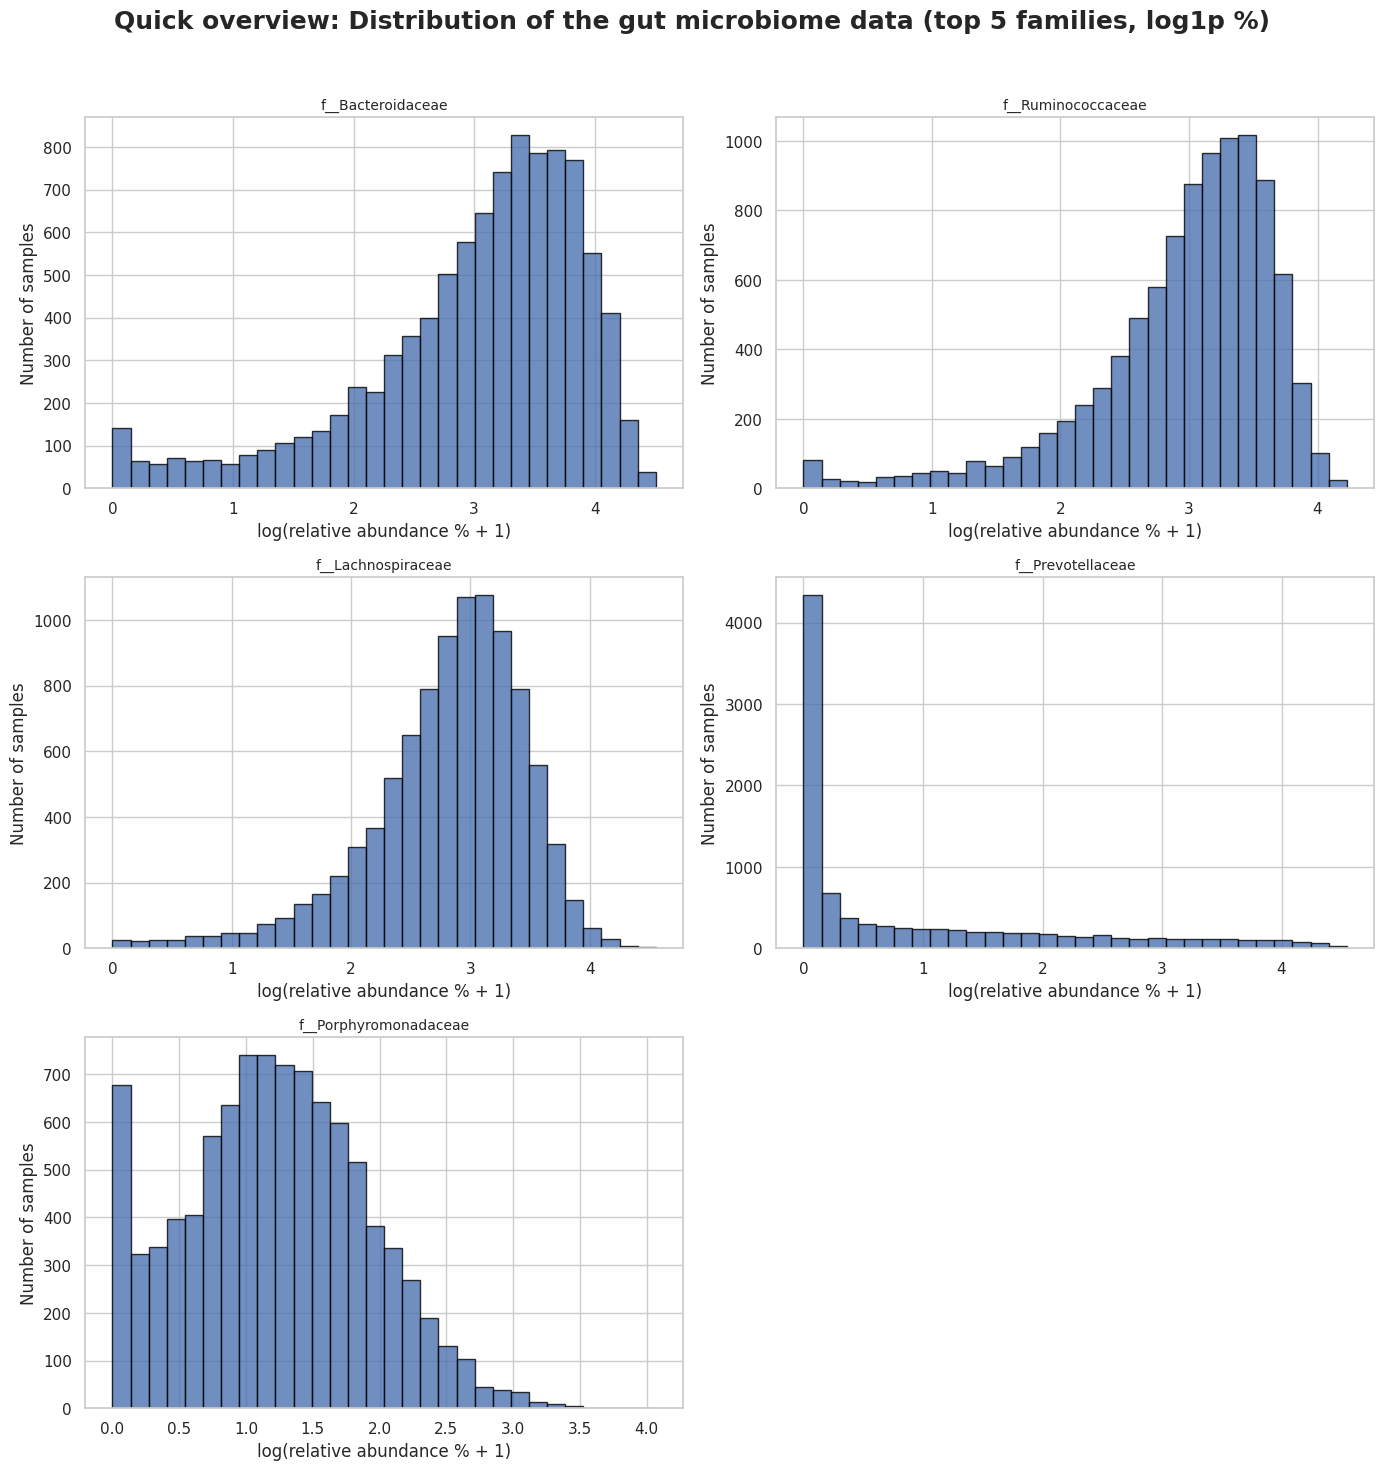

In [18]:
# ================================
# 20) Plot log1p-transformed percentage distributions for the top 5 families
# ================================
plot_selected_taxa_histograms(
    selected_family_logpct,
    taxa=selected_families,
    title="Quick overview: Distribution of the gut microbiome data (top 5 families, log1p %)",
    xlab="log(relative abundance % + 1)",
    outfile=output_dir / "top5_families_log1p_percentage_distribution.png",
    bins=30,
    ncols=2
)

In [19]:
def plot_selected_taxa_histograms_pretty(df,
                                         taxa,
                                         title,
                                         xlab,
                                         outfile=None,
                                         bins=30,
                                         ncols=2,
                                         figsize_scale=(7.5, 5.2)):
    n = len(taxa)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_scale[0] * ncols, figsize_scale[1] * nrows),
        squeeze=False
    )
    axes = axes.flatten()

    for ax, taxon in zip(axes, taxa):
        vals = df[taxon].dropna().to_numpy()
        ax.hist(vals, bins=bins, edgecolor="#4a4a4a", alpha=0.85)
        ax.set_title(str(taxon), fontsize=10)
        ax.set_xlabel(xlab, fontsize=11)
        ax.set_ylabel("Number of samples", fontsize=11)
        ax.tick_params(axis="both", labelsize=10)

    for ax in axes[len(taxa):]:
        ax.axis("off")

    fig.suptitle(
        title,
        fontsize=28,
        fontweight="bold",
        color="#1f2a8a",
        y=1.02
    )
    plt.tight_layout()

    if outfile is not None:
        fig.savefig(outfile, dpi=300, bbox_inches="tight")
        print("Saved:", outfile)

    plt.show()

Saved: hongrui_result/AGP_OTU_distribution_characterization/top5_families_percentage_distribution_pretty.png


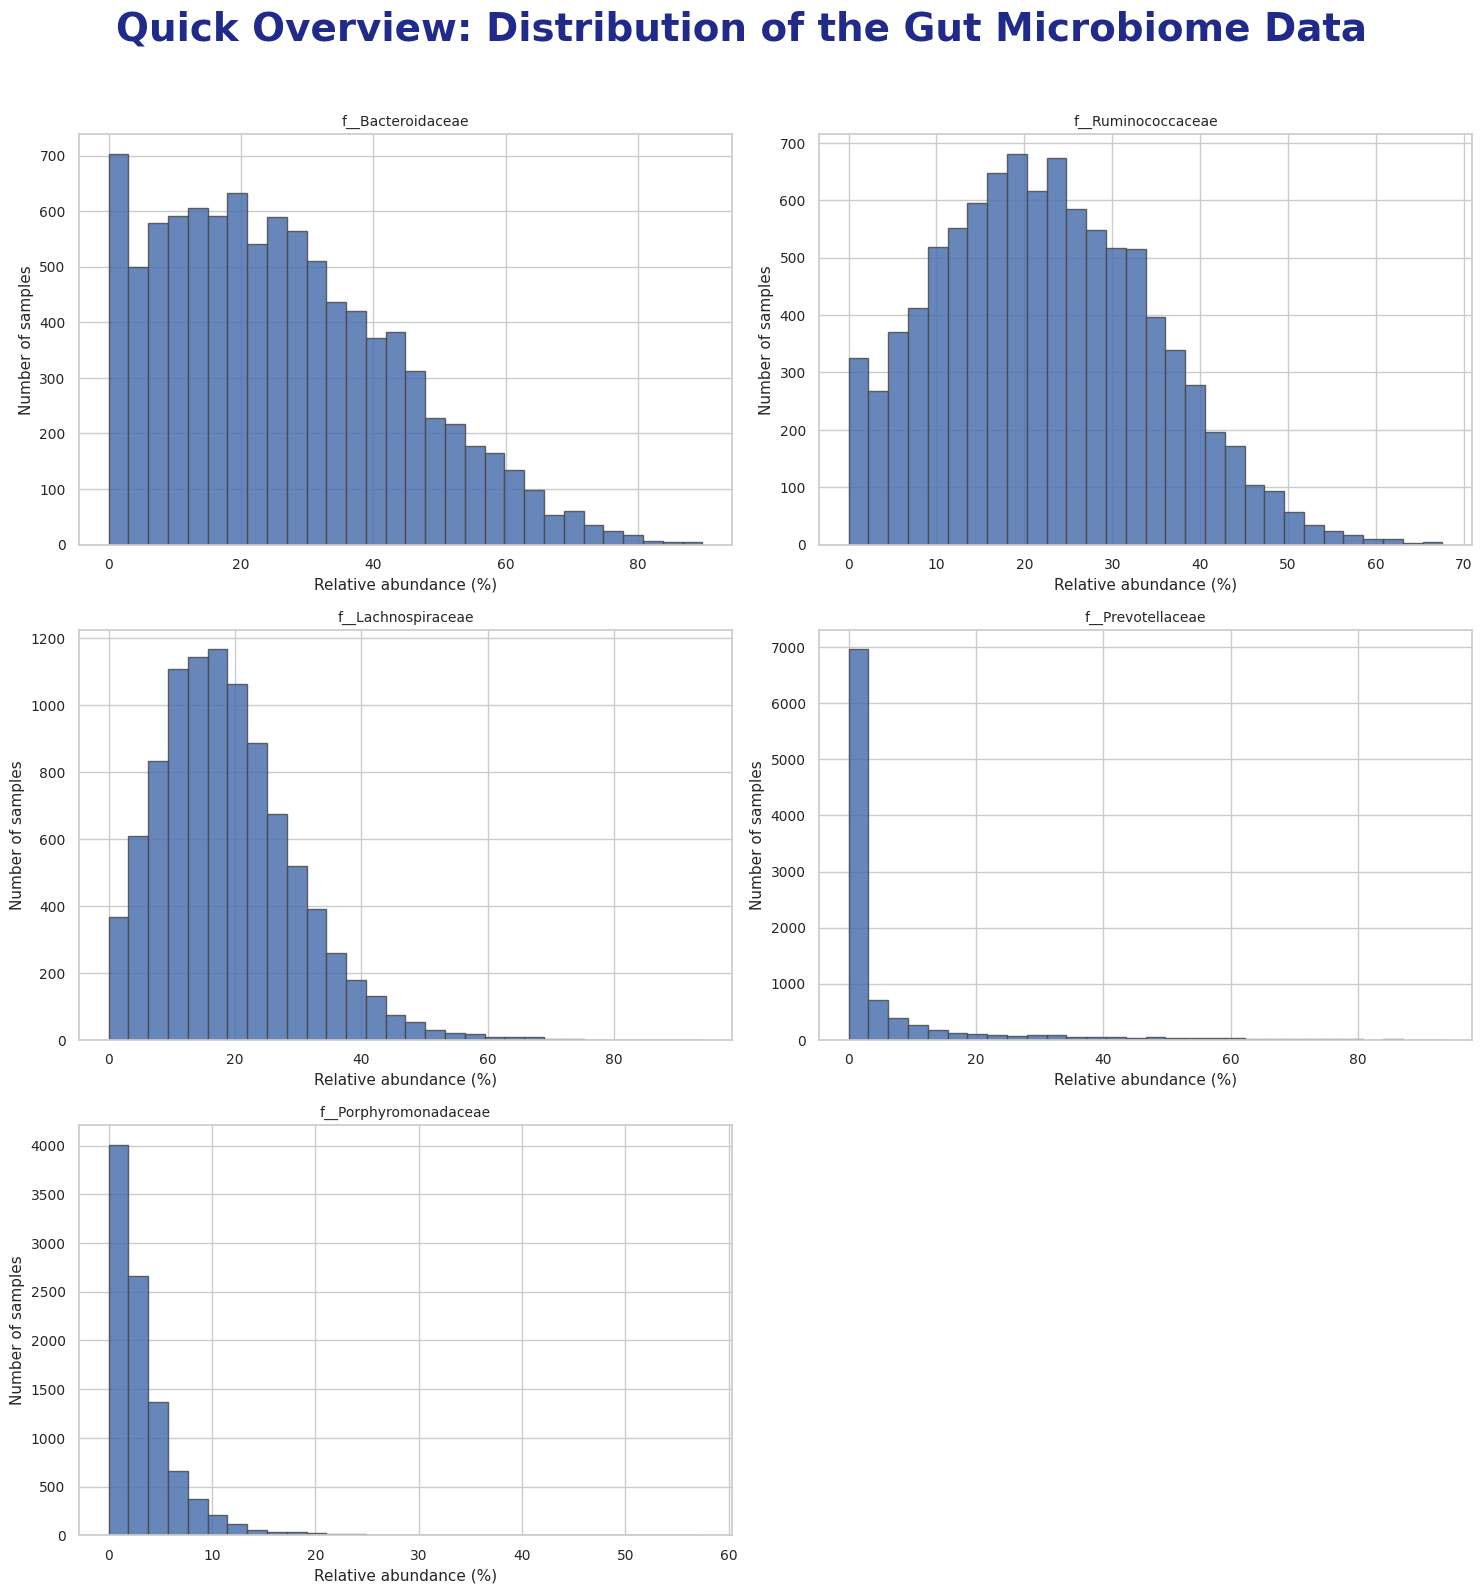

In [20]:
plot_selected_taxa_histograms_pretty(
    selected_family_pct,
    taxa=selected_families,
    title="Quick Overview: Distribution of the Gut Microbiome Data",
    xlab="Relative abundance (%)",
    outfile=output_dir / "top5_families_percentage_distribution_pretty.png",
    bins=30,
    ncols=2
)

Saved: hongrui_result/AGP_OTU_distribution_characterization/top5_families_log1p_percentage_distribution_pretty.png


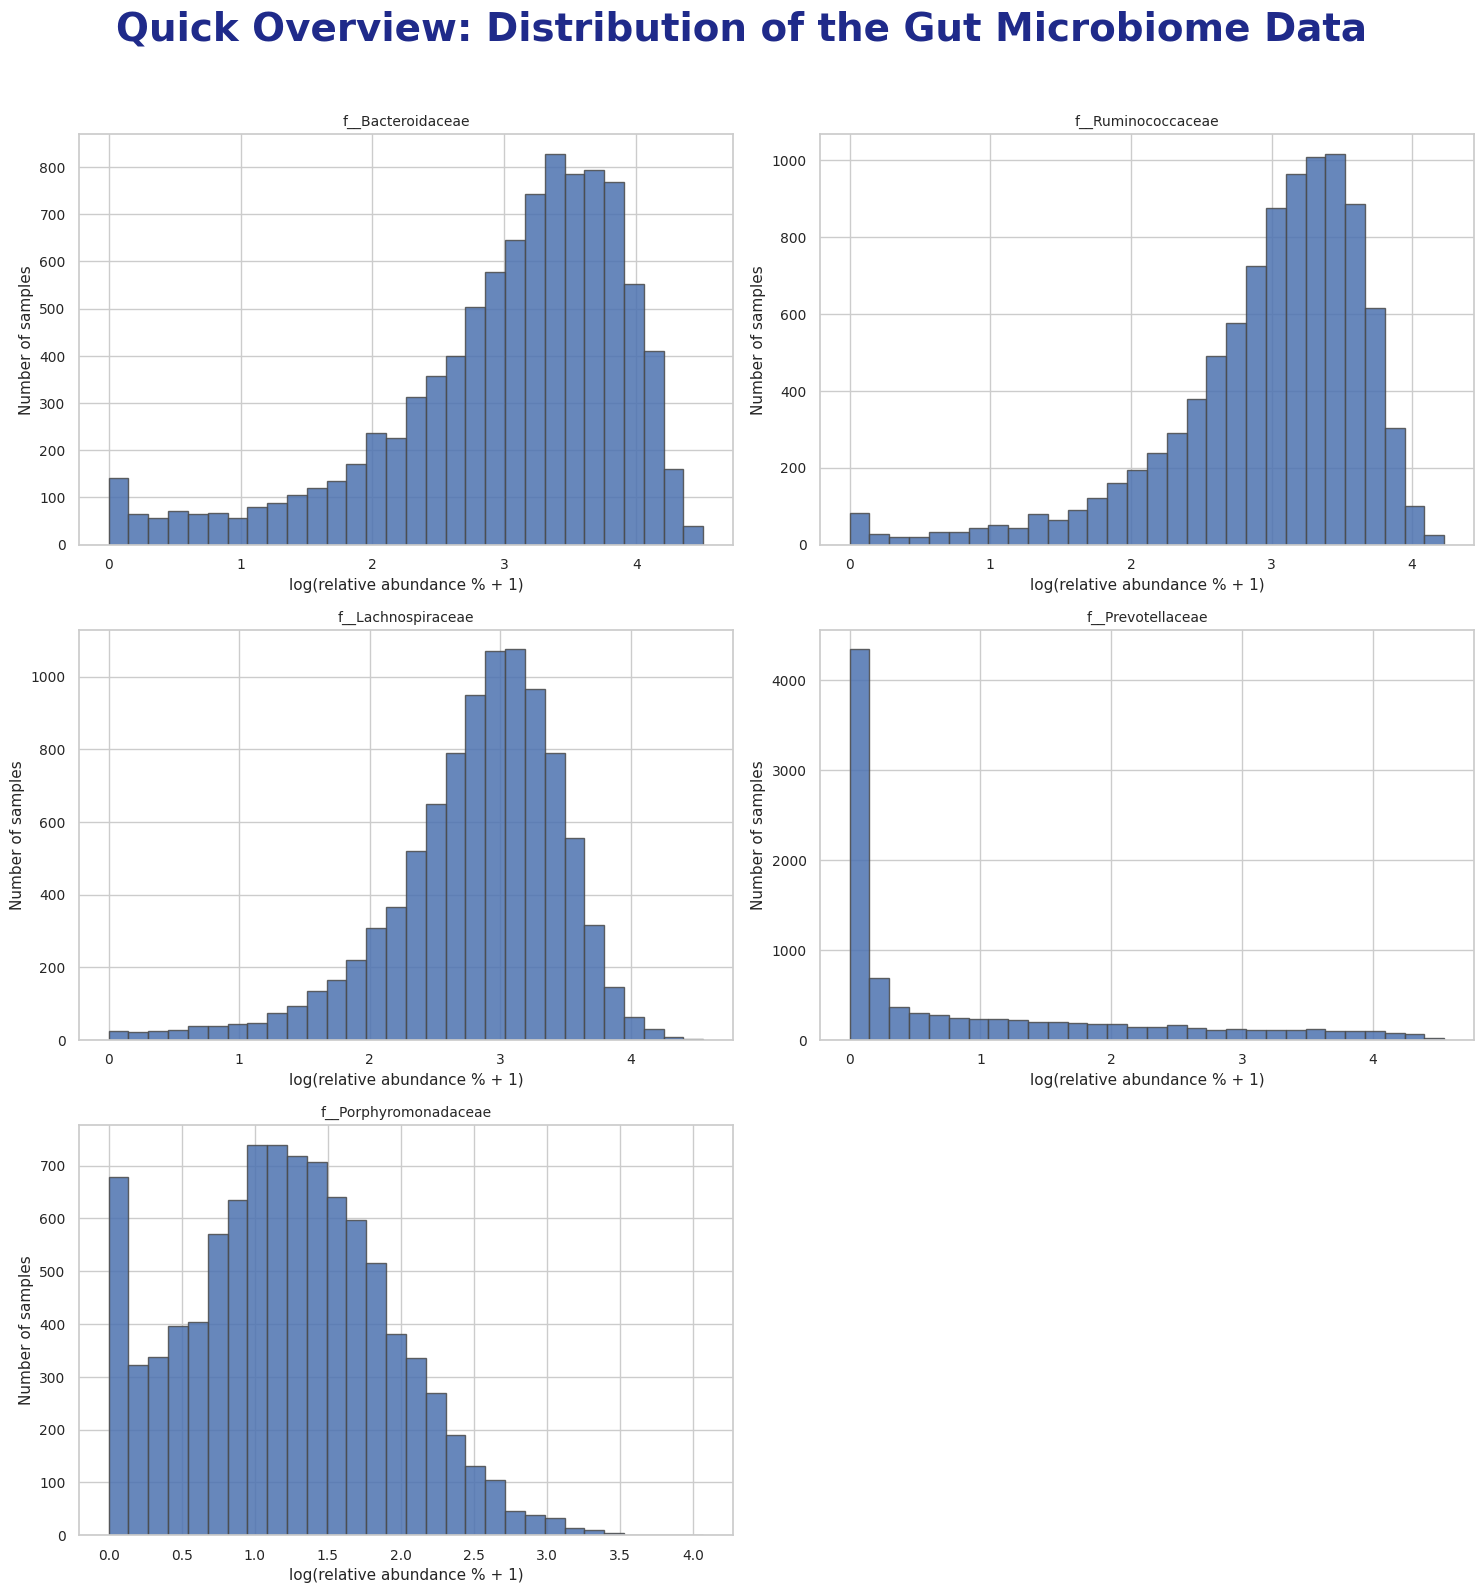

In [21]:
plot_selected_taxa_histograms_pretty(
    selected_family_logpct,
    taxa=selected_families,
    title="Quick Overview: Distribution of the Gut Microbiome Data",
    xlab="log(relative abundance % + 1)",
    outfile=output_dir / "top5_families_log1p_percentage_distribution_pretty.png",
    bins=30,
    ncols=2
)

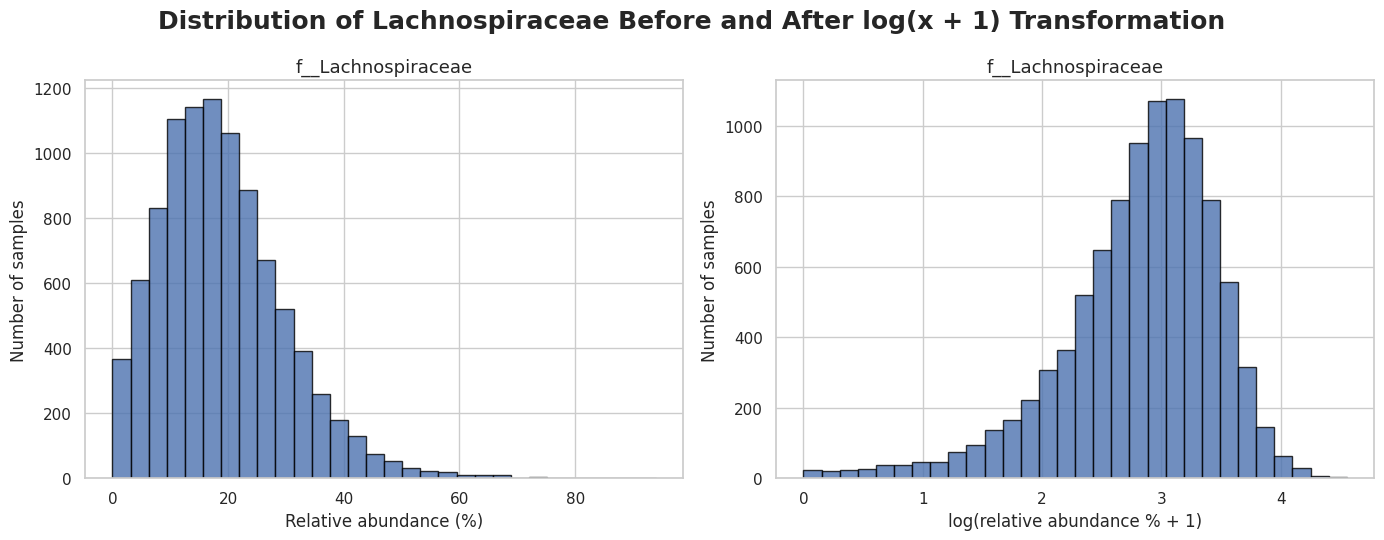

In [22]:
# =========================================
# Side-by-side plot for Lachnospiraceae
# Left: raw relative abundance (%)
# Right: log(relative abundance % + 1)
# =========================================

import numpy as np
import matplotlib.pyplot as plt

family_name = "f__Lachnospiraceae"   # change if your label is slightly different

# family_rel should be family-level relative abundance matrix in proportions (0-1)
# if not already created:
# family_counts = collapse_counts_by_level(otu_df, taxonomy_lookup, level="Family")
# family_rel = to_relative_abundance(family_counts)

raw_pct = family_rel[family_name] * 100.0
log_pct = np.log1p(raw_pct)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: raw %
axes[0].hist(raw_pct.dropna(), bins=30, edgecolor="black", alpha=0.8)
axes[0].set_title("f__Lachnospiraceae", fontsize=13)
axes[0].set_xlabel("Relative abundance (%)", fontsize=12)
axes[0].set_ylabel("Number of samples", fontsize=12)

# Right: log transformed
axes[1].hist(log_pct.dropna(), bins=30, edgecolor="black", alpha=0.8)
axes[1].set_title("f__Lachnospiraceae", fontsize=13)
axes[1].set_xlabel("log(relative abundance % + 1)", fontsize=12)
axes[1].set_ylabel("Number of samples", fontsize=12)

fig.suptitle(
    "Distribution of Lachnospiraceae Before and After log(x + 1) Transformation",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Saved: hongrui_result/AGP_OTU_distribution_characterization/lachnospiraceae_raw_vs_log1p_distribution.png


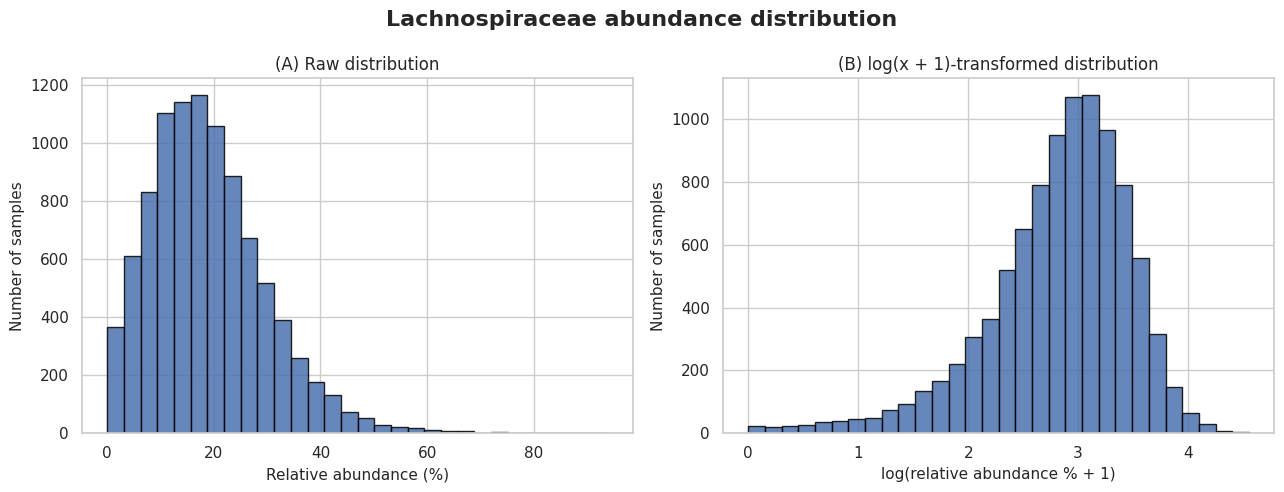

In [23]:
import numpy as np
import matplotlib.pyplot as plt

family_name = "f__Lachnospiraceae"

raw_pct = family_rel[family_name] * 100.0
log_pct = np.log1p(raw_pct)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

axes[0].hist(raw_pct.dropna(), bins=30, edgecolor="black", alpha=0.85)
axes[0].set_title("(A) Raw distribution", fontsize=12)
axes[0].set_xlabel("Relative abundance (%)", fontsize=11)
axes[0].set_ylabel("Number of samples", fontsize=11)

axes[1].hist(log_pct.dropna(), bins=30, edgecolor="black", alpha=0.85)
axes[1].set_title("(B) log(x + 1)-transformed distribution", fontsize=12)
axes[1].set_xlabel("log(relative abundance % + 1)", fontsize=11)
axes[1].set_ylabel("Number of samples", fontsize=11)

fig.suptitle("Lachnospiraceae abundance distribution", fontsize=16, fontweight="bold")

plt.tight_layout()

save_path = output_dir / "lachnospiraceae_raw_vs_log1p_distribution.png"
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print("Saved:", save_path)

plt.show()